# Demo Normal Norm Calibration

This notebook demonstrates how to use `calibrate_score_to_normal` to normalize different types of distributions:
1. Skewed distributions (right, left) - ✓ works
2. U-shaped distribution (extreme values) - ✓ works
3. Uniform distribution - ✗ no effect
4. Bimodal distribution (2 peaks) - ✗ doesn't work

In [7]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, uniform
from caketool.calibration.normal_norm import calibrate_score_to_normal

np.random.seed(42)

In [8]:
# 1. Right-skewed distribution
skewed_scores = beta.rvs(2, 8, size=5000)
skewed_calibrated_std = calibrate_score_to_normal(skewed_scores, standard=True)

# 2. Left-skewed distribution
left_skewed = beta.rvs(8, 2, size=5000)
left_calibrated_std = calibrate_score_to_normal(left_skewed, standard=True)

# 3. U-shaped distribution (extreme values concentrated at 0 and 1)
u_shaped = beta.rvs(0.5, 0.5, size=5000)
u_shaped_calibrated_std = calibrate_score_to_normal(u_shaped, standard=True)

# 4. Uniform distribution - NO EFFECT (already balanced)
uniform_scores = uniform.rvs(0.1, 0.8, size=5000)
uniform_calibrated_std = calibrate_score_to_normal(uniform_scores, standard=True)

# 5. Bimodal distribution (2 peaks) - NOT SUITABLE for this calibration method
peak1 = beta.rvs(5, 20, size=2500)
peak2 = beta.rvs(20, 5, size=2500)
bimodal_scores = np.concatenate([peak1, peak2])
bimodal_calibrated_std = calibrate_score_to_normal(bimodal_scores, standard=True)

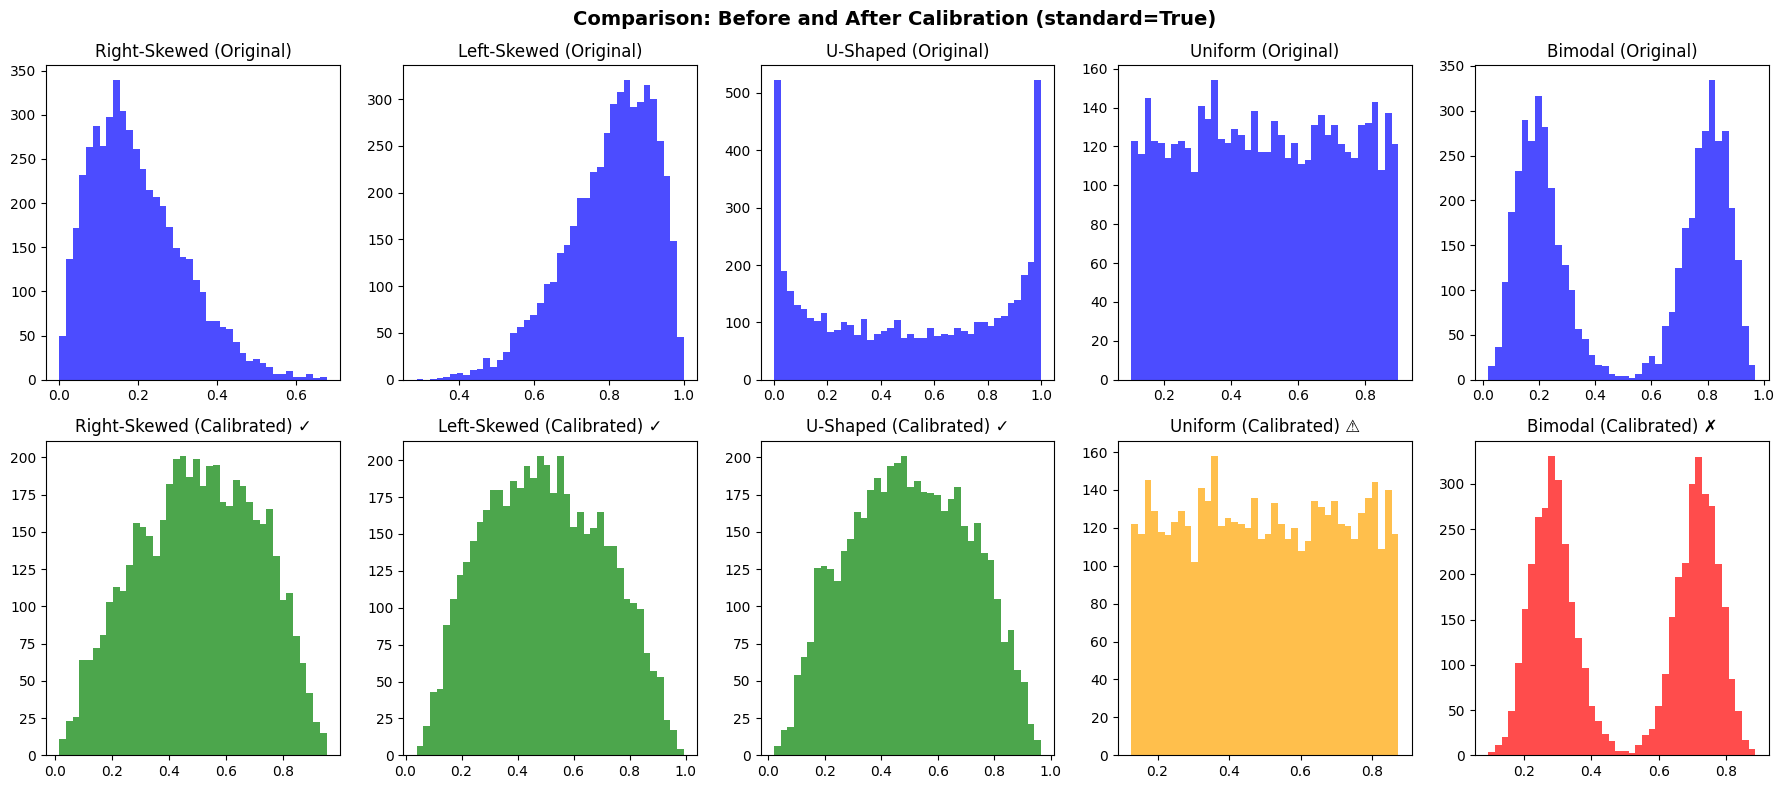

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

# Row 1: Original
axes[0, 0].hist(skewed_scores, bins=40, alpha=0.7, color='blue')
axes[0, 0].set_title('Right-Skewed (Original)')

axes[0, 1].hist(left_skewed, bins=40, alpha=0.7, color='blue')
axes[0, 1].set_title('Left-Skewed (Original)')

axes[0, 2].hist(u_shaped, bins=40, alpha=0.7, color='blue')
axes[0, 2].set_title('U-Shaped (Original)')

axes[0, 3].hist(uniform_scores, bins=40, alpha=0.7, color='blue')
axes[0, 3].set_title('Uniform (Original)')

axes[0, 4].hist(bimodal_scores, bins=40, alpha=0.7, color='blue')
axes[0, 4].set_title('Bimodal (Original)')

# Row 2: Calibrated (standard=True)
axes[1, 0].hist(skewed_calibrated_std, bins=40, alpha=0.7, color='green')
axes[1, 0].set_title('Right-Skewed (Calibrated) ✓')

axes[1, 1].hist(left_calibrated_std, bins=40, alpha=0.7, color='green')
axes[1, 1].set_title('Left-Skewed (Calibrated) ✓')

axes[1, 2].hist(u_shaped_calibrated_std, bins=40, alpha=0.7, color='green')
axes[1, 2].set_title('U-Shaped (Calibrated) ✓')

axes[1, 3].hist(uniform_calibrated_std, bins=40, alpha=0.7, color='orange')
axes[1, 3].set_title('Uniform (Calibrated) ⚠')

axes[1, 4].hist(bimodal_calibrated_std, bins=40, alpha=0.7, color='red')
axes[1, 4].set_title('Bimodal (Calibrated) ✗')

plt.suptitle('Comparison: Before and After Calibration (standard=True)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion

- ✅ **Skewed distributions**: Calibration works well, pulls extreme values toward center
- ✅ **U-shaped distribution**: Works - pulls values from extremes to center
- ⚠️ **Uniform distribution**: No visible effect - already balanced, calibration is pointless
- ❌ **Bimodal distribution**: Does NOT work - still retains 2 peaks

**Recommendations:**
- For uniform: No need to calibrate
- For bimodal: Use Isotonic Regression or Platt Scaling with supervised signal